In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import lightgbm as lgb
from sklearn.model_selection import train_test_split

from scipy.stats import spearmanr

from datetime import datetime

In [66]:
from sklearn.model_selection import ParameterGrid
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

In [99]:
train_df = pd.read_parquet("/Users/sudhanvabharadwaj/Documents/Full_Quant_Pipeline/Data/processed/train_normalized_df.parquet")

rank_cols = [col for col in train_df.columns if '_rank' in col]
train_df = train_df.drop(columns=rank_cols)

test_df = pd.read_parquet("/Users/sudhanvabharadwaj/Documents/Full_Quant_Pipeline/Data/processed/test_normalized_df.parquet")

rank_cols = [col for col in test_df.columns if '_rank' in col]
test_df = test_df.drop(columns=rank_cols)

val_df = pd.read_parquet("/Users/sudhanvabharadwaj/Documents/Full_Quant_Pipeline/Data/processed/val_normalized_df.parquet")

rank_cols = [col for col in val_df.columns if '_rank' in col]
val_df = val_df.drop(columns=rank_cols)

In [100]:
feature_cols = [
    c for c in train_df.columns
    if c not in ["date","ticker", "fwd_return_5d"]
]

x_train = train_df[feature_cols]
y_train = train_df["fwd_return_5d"]

x_val = val_df[feature_cols]
y_val = val_df["fwd_return_5d"]

x_test = test_df[feature_cols]
y_test = test_df["fwd_return_5d"]

In [101]:
val = val_df.copy()

train = train_df.copy()

In [102]:
# LightGBM parameters
lgb_params = {
    "objective": "regression",
    "metric": "rmse",
    "learning_rate": 0.01,
    "num_leaves": 31,
    "max_depth": 5,
    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq": 5,
    "verbose": -1
}

train_data = lgb.Dataset(x_train, label=y_train)
val_data   = lgb.Dataset(x_val, label=y_val, reference=train_data)

# Train
lgbm_model1 = lgb.train(
    lgb_params,
    train_data,
    num_boost_round=5000,
    valid_sets=[train_data, val_data],
    #early_stopping_rounds=100,
    #verbose_eval=100
)

In [104]:
train_df['pred'] = lgbm_model1.predict(x_train)
val_df['pred'] = lgbm_model1.predict(x_val)
test_df['pred'] = lgbm_model1.predict(x_test)

In [105]:
train_df1 = train_df.copy()
val_df1 = val_df.copy()
test_df1 = test_df.copy()

In [106]:
def daily_ic(df):
    
    ic_vals = []

    for d, grp in df.groupby("date"):
        
        if grp["pred"].std() == 0:
            continue
            
        ic = spearmanr(grp["pred"], grp["fwd_return_5d"])[0]
        ic_vals.append(ic)

    return np.array(ic_vals)

In [107]:
train_ic = daily_ic(train_df1)

# Summary
print("Training IC mean:", train_ic.mean(), "IC IR:", train_ic.mean()/train_ic.std())

Training IC mean: 0.4191942845698498 IC IR: 2.580970928128484


In [108]:
val_ic = daily_ic(val_df1)
test_ic = daily_ic(test_df1)

# Summary
print("Validation IC mean:", val_ic.mean(), "IC IR:", val_ic.mean()/val_ic.std())
print("Test IC mean:", test_ic.mean(), "IC IR:", test_ic.mean()/test_ic.std())

Validation IC mean: 0.00043877423389618287 IC IR: 0.002235254194759568
Test IC mean: 0.004490692919029452 IC IR: 0.02738127576816149


Peformed much weaker than RF. Probably because the model is highly complex for a simple dataset like the current one

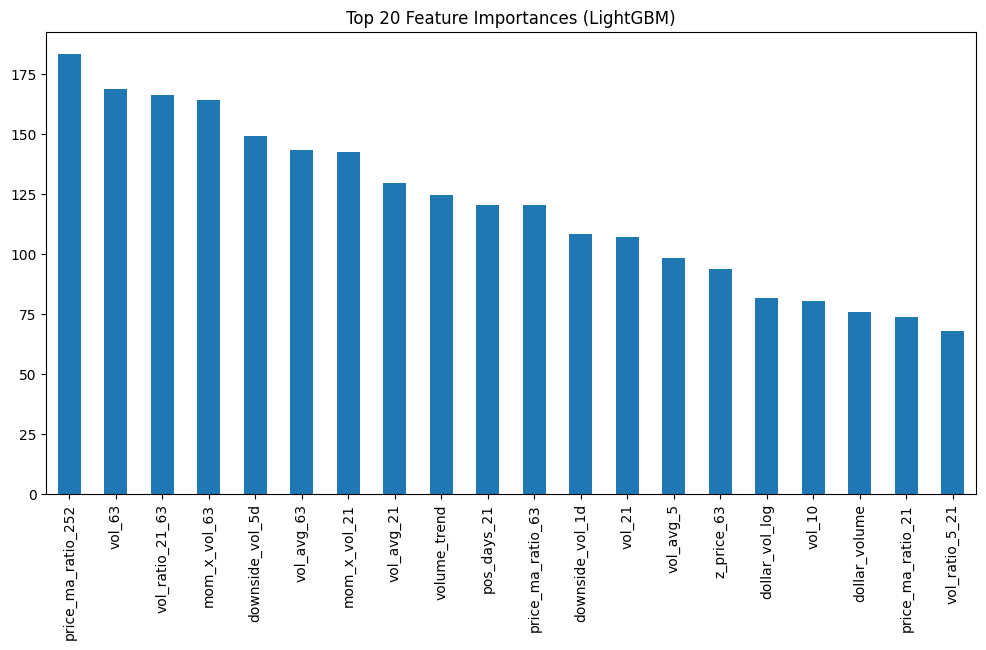

In [111]:
# Feature importance
importance = pd.Series(lgbm_model1.feature_importance(importance_type='gain'), index=feature_cols)
importance.sort_values(ascending=False, inplace=True)

plt.figure(figsize=(12,6))
importance.head(20).plot(kind='bar')
plt.title("Top 20 Feature Importances (LightGBM)")
plt.show()

Trying a simpler LightGBM model:

In [ ]:
lgb_params_simple = {
    "objective": "regression",
    "metric": "rmse",          
    "learning_rate": 0.05,     
    "num_leaves": 15,          
    "max_depth": 4,           
    "min_data_in_leaf": 50,    
    "feature_fraction": 0.7,  
    "bagging_fraction": 0.7,  
    "bagging_freq": 1,         
    "lambda_l1": 0.1,        
    "lambda_l2": 0.1,         
    "verbosity": -1,
    "seed": 42
}

In [113]:
train_data = lgb.Dataset(x_train, label=y_train)
val_data   = lgb.Dataset(x_val, label=y_val, reference=train_data)

# Train
lgbm_model2 = lgb.train(
    lgb_params_simple,
    train_data,
    num_boost_round=500,
    valid_sets=[train_data, val_data],
    #early_stopping_rounds=100,
    #verbose_eval=100
)

train_df['pred'] = lgbm_model2.predict(x_train)
val_df['pred'] = lgbm_model2.predict(x_val)
test_df['pred'] = lgbm_model2.predict(x_test)

In [114]:
train_df2 = train_df.copy()
val_df2 = val_df.copy()
test_df2 = test_df.copy()

In [ ]:
train_ic = daily_ic(train_df2)

print("Training IC mean:", train_ic.mean(), "IC IR:", train_ic.mean()/train_ic.std())

val_ic = daily_ic(val_df2)
test_ic = daily_ic(test_df2)

print("Validation IC mean:", val_ic.mean(), "IC IR:", val_ic.mean()/val_ic.std())
print("Test IC mean:", test_ic.mean(), "IC IR:", test_ic.mean()/test_ic.std())

Training IC mean: 0.2083446813938435 IC IR: 1.1205993249410435
Validation IC mean: 0.002371982489055661 IC IR: 0.011127993755416041
Test IC mean: 0.00870206800598689 IC IR: 0.05162605642415821


Better than the more complex version

------

Portfolio construction, Backtesting and Visualization

------

In [116]:
import portfolio_cons_backtest
import importlib

importlib.reload(portfolio_cons_backtest)

<module 'portfolio_cons_backtest' from '/Users/sudhanvabharadwaj/Documents/Full_Quant_Pipeline/src/portfolio_cons_backtest.py'>

In [117]:
from portfolio_cons_backtest import *

In [134]:
def perf_pipeline(val_df):
    
    val_df = construct_portfolio(val_df, pred_col='pred', top_pct=0.2, bottom_pct=0.2)

    portfolio_returns = stock_pnl_and_returns(val_df)

    portfolio_returns = turnover(val_df, portfolio_returns)

    portfolio_returns = apply_transaction_costs(portfolio_returns)

    metrics = performance_metrics(portfolio_returns, return_col='net_return', freq=52)
    
    print(metrics)
    
perf_pipeline(val_df2)

Position sum check (should be ~0): 0.000000
{'total_return': np.float64(-0.5133224085224595), 'ann_return': np.float64(-0.08391952715253764), 'ann_vol': np.float64(0.17825220967385405), 'sharpe': np.float64(-0.4707909501154808), 'max_drawdown': np.float64(-0.8045606458778332), 'win_rate': np.float64(0.464), 'avg_turnover': np.float64(1.4397037037037037), 'avg_cost': np.float64(0.001439703703703704), 'n_periods': 375}


In [120]:
print(metrics)

{'total_return': np.float64(-0.5133224085224595), 'ann_return': np.float64(-0.08391952715253764), 'ann_vol': np.float64(0.17825220967385405), 'sharpe': np.float64(-0.4707909501154808), 'max_drawdown': np.float64(-0.8045606458778332), 'win_rate': np.float64(0.464), 'avg_turnover': np.float64(1.4397037037037037), 'avg_cost': np.float64(0.001439703703703704), 'n_periods': 375}


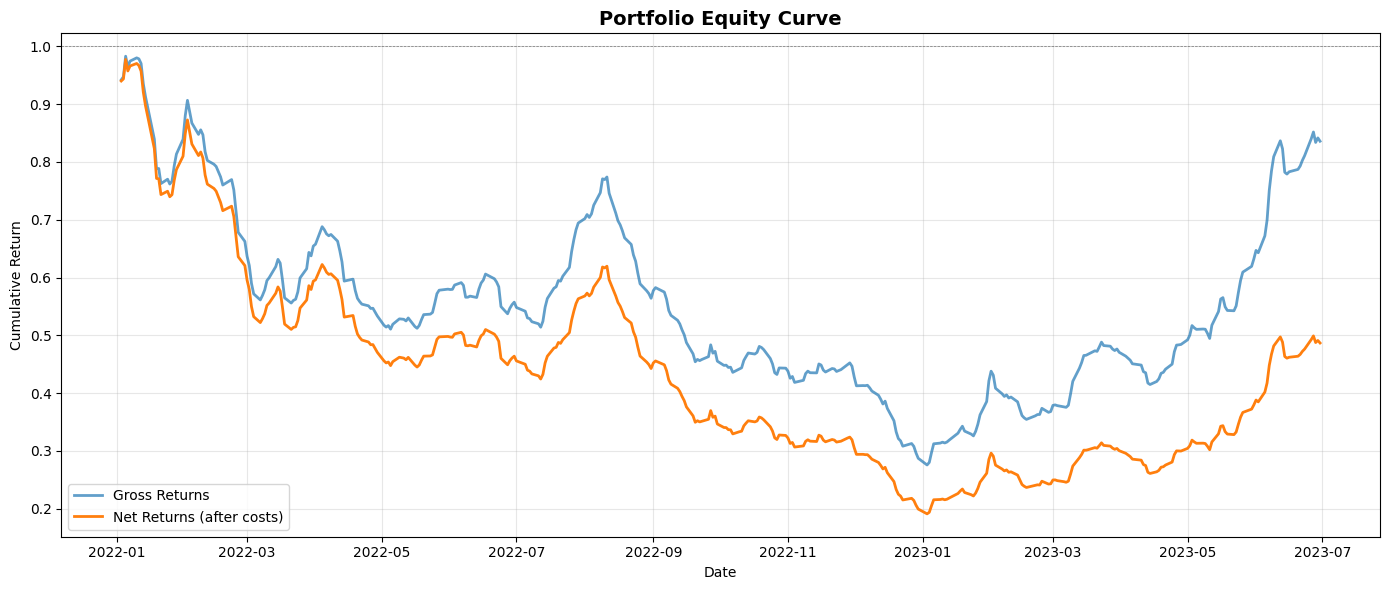

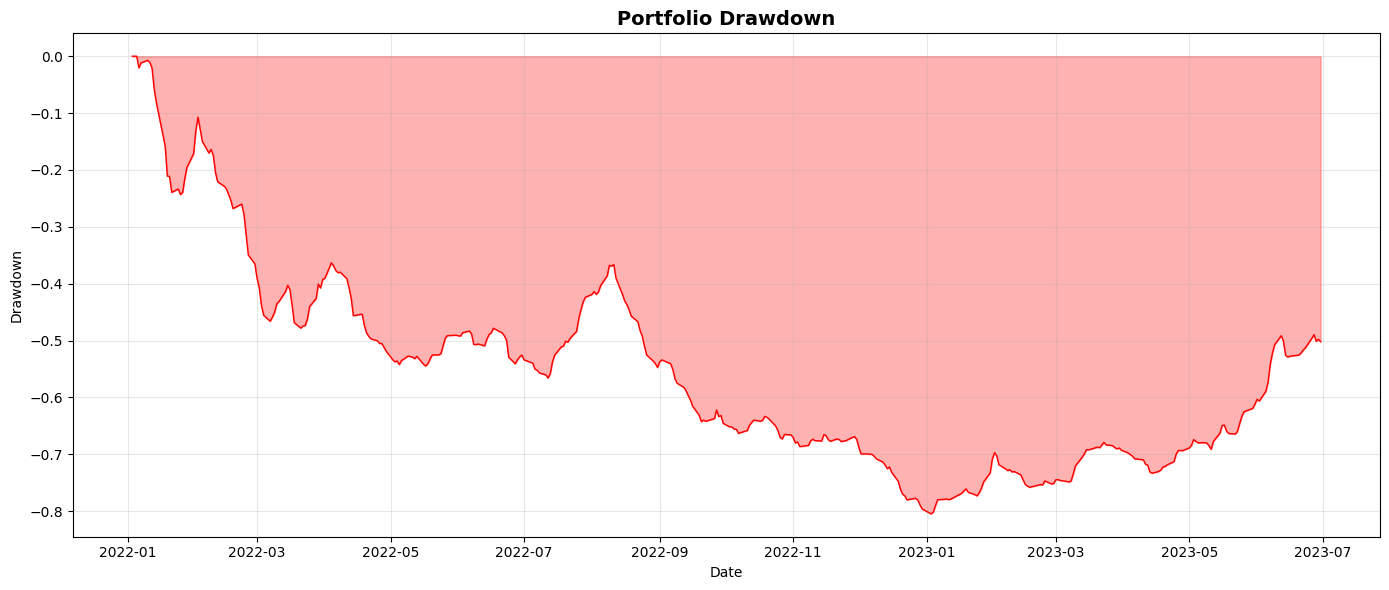

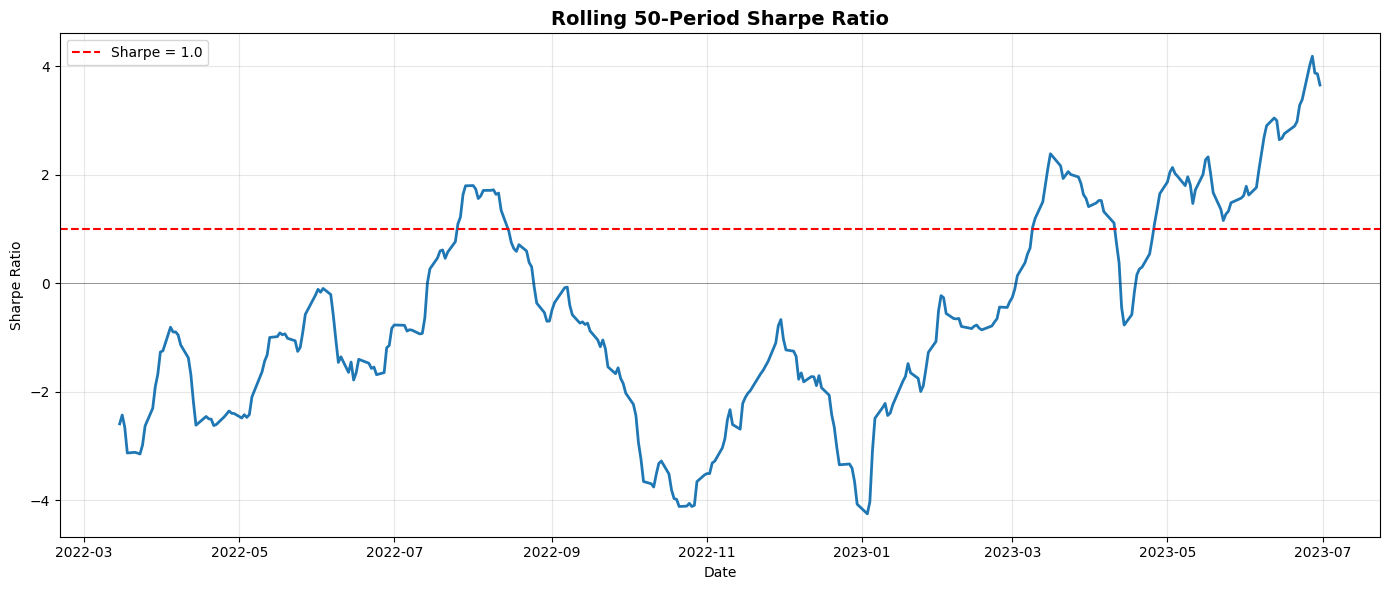

In [121]:
plots(portfolio_returns)

-------

Hyperparameter Tuning for better performance

---------

In [122]:
val_df.columns

Index(['date', 'ticker', 'fwd_return_5d', 'dollar_volume', 'price_ma_ratio_5',
       'price_ma_ratio_10', 'price_ma_ratio_21', 'price_ma_ratio_63',
       'price_ma_ratio_252', 'pos_days_21', 'z_price_21', 'z_price_63',
       'z_return_1d_5', 'z_return_1d_21', 'z_return_1d_35', 'z_return_5d_5',
       'z_return_5d_21', 'z_return_5d_35', 'rev_1d', 'rev_5d', 'vol_5',
       'vol_10', 'vol_21', 'vol_63', 'vol_ratio_21_63', 'vol_ratio_5_21',
       'hl_range', 'downside_vol_1d', 'downside_vol_5d', 'vol_avg_5',
       'vol_avg_21', 'vol_avg_63', 'dollar_vol_log', 'volume_trend',
       'mom_x_vol_5', 'mom_x_vol_21', 'mom_x_vol_63', 'pred'],
      dtype='object')

In [124]:
def calculate_ic(predictions, df_subset):

    temp_df = df_subset.copy()
    temp_df['prediction'] = predictions
    
    ic_by_date = temp_df.groupby('date').apply(
        lambda x: spearmanr(x['prediction'], x['fwd_return_5d'])[0]
        if len(x) >= 10 and x['prediction'].std() > 0
        else np.nan
    )
    
    return ic_by_date.mean()

In [ ]:
# Coarse Grid Search for tuning
from lightgbm import LGBMRegressor
param_grid = {
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [15, 31, 63],
    'max_depth': [3, 5, 7],
    'min_child_samples': [20, 50, 100],
    'reg_alpha': [0.0, 0.1],
    'reg_lambda': [0.0, 0.1]
}

results = []

for params in tqdm(ParameterGrid(param_grid), desc="Tuning"):
    
    lgbm_model3 = LGBMRegressor(
        **params,
        n_estimators=100,  
        random_state=42,
        verbose=-1,
        force_col_wise=True  
    )
    

    lgbm_model3.fit(
        x_train, y_train,
        eval_set=[(x_val, y_val)],
        callbacks=[
            lgb.early_stopping(stopping_rounds=10, verbose=False),
            lgb.log_evaluation(period=0)
        ]
    )
    
    # Evaluating on validation
    predictions = lgbm_model3.predict(x_val)
    val_ic = calculate_ic(predictions, val_df)

    result = params.copy()
    result['val_ic'] = val_ic
    result['n_estimators_used'] = lgbm_model3.best_iteration_ if hasattr(lgbm_model3, 'best_iteration_') else 100
    
    results.append(result)

Tuning: 100%|██████████| 324/324 [01:36<00:00,  3.36it/s]


In [127]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values('val_ic', ascending=False)

print("TOP 10 PARAMETER COMBINATIONS")

print(results_df.head(10).to_string(index=False))

TOP 10 PARAMETER COMBINATIONS
 learning_rate  max_depth  min_child_samples  num_leaves  reg_alpha  reg_lambda   val_ic  n_estimators_used
          0.05          7                 20          15        0.1         0.1 0.029919                 11
          0.05          7                 20          15        0.1         0.0 0.029919                 11
          0.01          7                 20          15        0.0         0.0 0.029742                 59
          0.01          7                 20          15        0.1         0.0 0.029447                 18
          0.10          5                100          15        0.1         0.0 0.029213                 10
          0.10          5                100          15        0.1         0.1 0.029156                 10
          0.10          7                100          15        0.0         0.1 0.029088                  7
          0.10          7                100          15        0.0         0.0 0.029088                  

In [ ]:
# Best parameters

best_params = results_df.iloc[0].to_dict()
best_ic = best_params.pop('val_ic')
best_n_estimators = int(best_params.pop('n_estimators_used'))

print("BEST PARAMETERS (Phase 1)")
for param, value in best_params.items():
    print(f"  {param}: {value}")
print(f"  n_estimators: {best_n_estimators}")
print(f"\nValidation IC: {best_ic:.4f}")

BEST PARAMETERS (Phase 1)
  learning_rate: 0.05
  max_depth: 7.0
  min_child_samples: 20.0
  num_leaves: 15.0
  reg_alpha: 0.1
  reg_lambda: 0.1
  n_estimators: 11

Validation IC: 0.0299


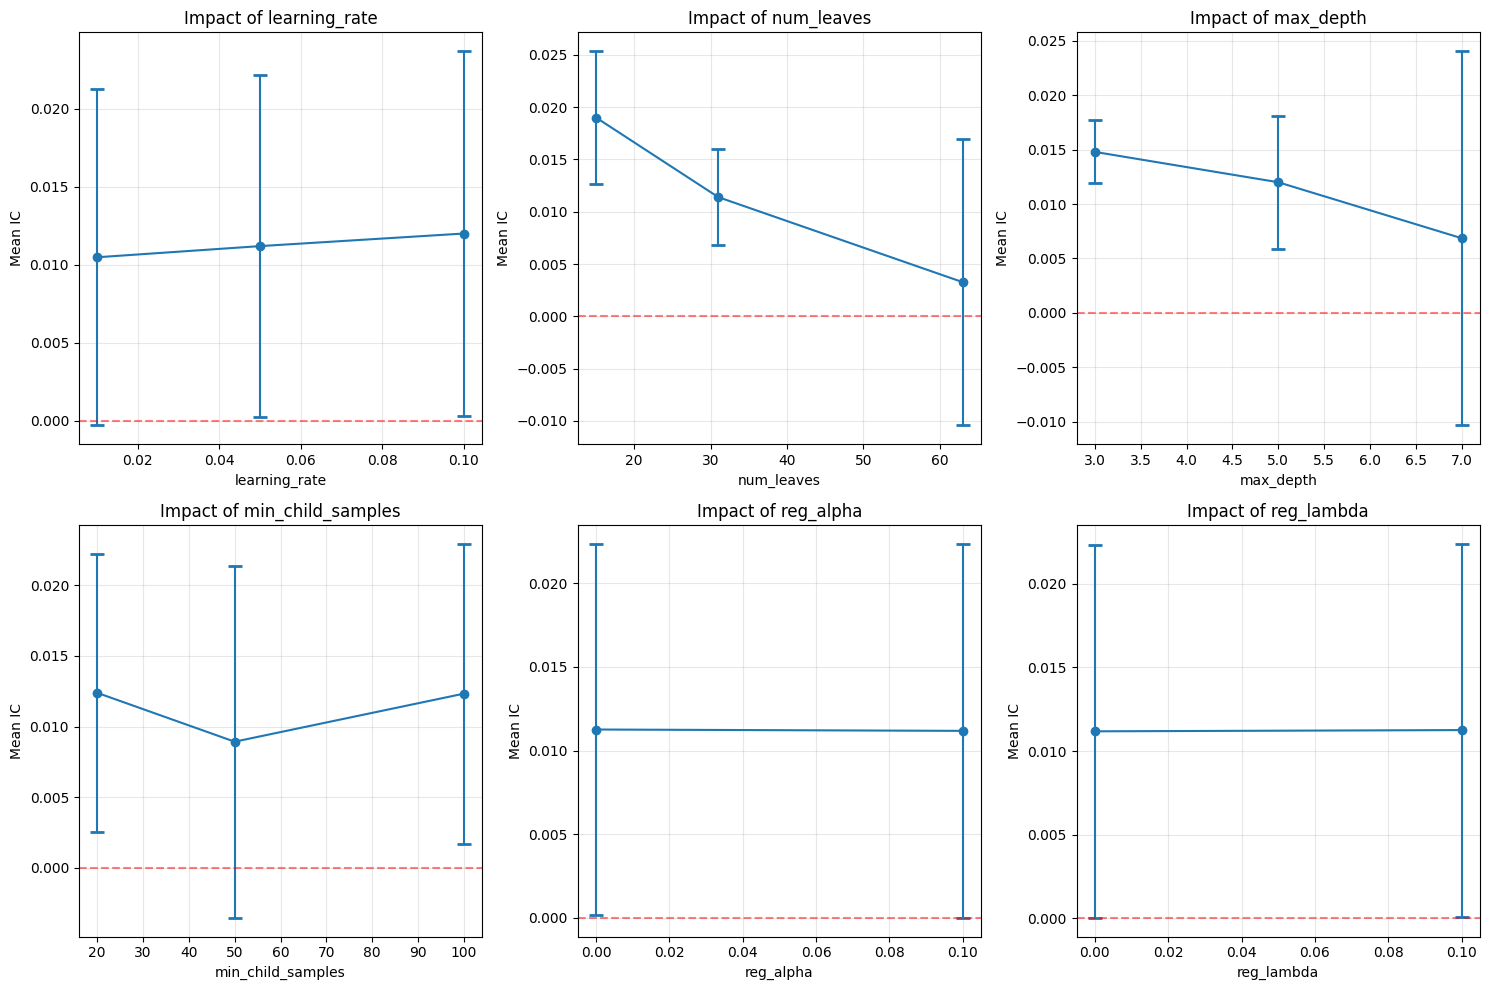

In [ ]:
# Plotting IC by parameter
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, param in enumerate(param_grid.keys()):
    ax = axes[idx]
    
    # Group by the parameter
    param_impact = results_df.groupby(param)['val_ic'].agg(['mean', 'std', 'count'])

    ax.errorbar(
        param_impact.index,
        param_impact['mean'],
        yerr=param_impact['std'],
        marker='o',
        capsize=5,
        capthick=2
    )
    ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
    ax.set_xlabel(param)
    ax.set_ylabel('Mean IC')
    ax.set_title(f'Impact of {param}')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('hyperparameter_tuning_phase1.png', dpi=300, bbox_inches='tight')
plt.show()

In [83]:
for k in ['num_leaves', 'max_depth', 'min_child_samples']:
    if k in best_params:
        best_params[k] = int(best_params[k])

final_model = LGBMRegressor(
    **best_params,
    n_estimators=best_n_estimators,
    random_state=42,
    verbose=-1,
    force_col_wise=True
)

# Train on full training set
final_model.fit(x_train, y_train)

,boosting_type,'gbdt'
,num_leaves,15
,max_depth,7
,learning_rate,0.05
,n_estimators,11
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [ ]:
train_df['pred'] = final_model.predict(x_train)
val_df['pred'] = final_model.predict(x_val)
test_df['pred'] = final_model.predict(x_test)

train_ic = daily_ic(train_df)

print("Training IC mean:", train_ic.mean(), "IC IR:", train_ic.mean()/train_ic.std())

val_ic = daily_ic(val_df)
test_ic = daily_ic(test_df)

print("Validation IC mean:", val_ic.mean(), "IC IR:", val_ic.mean()/val_ic.std())
print("Test IC mean:", test_ic.mean(), "IC IR:", test_ic.mean()/test_ic.std())

Training IC mean: 0.04373976137379043 IC IR: 0.1915187682484971
Validation IC mean: 0.029919212686379634 IC IR: 0.12459405517786717
Test IC mean: 0.002974766020277716 IC IR: 0.011305314829750963


In [130]:
train_df4 = train_df.copy()
val_df4 = val_df.copy()
test_df4 = test_df.copy()

In [ ]:
Training IC mean: 0.2083446813938435 IC IR: 1.1205993249410435
Validation IC mean: 0.002371982489055661 IC IR: 0.011127993755416041
Test IC mean: 0.00870206800598689 IC IR: 0.05162605642415821

So hyperparameter tuning overfit the validation set noise

In [ ]:
def analyze_feature_ic_by_split(train, val, test, features):
    """
    Calculate IC for each feature on each split.
    Find which features work on test.
    """
    
    results = []
    
    for feature in features:
        
        # Train IC
        train_ic = train.groupby('date').apply(
            lambda x: spearmanr(x[feature], x['fwd_return_5d'])[0]
            if len(x) >= 10 else np.nan
        ).mean()
        
        # Val IC
        val_ic = val.groupby('date').apply(
            lambda x: spearmanr(x[feature], x['fwd_return_5d'])[0]
            if len(x) >= 10 else np.nan
        ).mean()
        
        # Test IC
        test_ic = test.groupby('date').apply(
            lambda x: spearmanr(x[feature], x['fwd_return_5d'])[0]
            if len(x) >= 10 else np.nan
        ).mean()
        
        results.append({
            'feature': feature,
            'train_ic': train_ic,
            'val_ic': val_ic,
            'test_ic': test_ic,
            'val_degradation': val_ic - train_ic,
            'test_degradation': test_ic - val_ic
        })
    
    results_df = pd.DataFrame(results)
    return results_df


print("="*60)
print("FEATURE IC ANALYSIS BY SPLIT")
print("="*60)

feature_analysis = analyze_feature_ic_by_split(train_df, val_df, test_df, feature_cols)

# Sort by test IC
feature_analysis_sorted = feature_analysis.sort_values('test_ic', key=abs, ascending=False)

print(feature_analysis_sorted.to_string(index=False))

FEATURE IC ANALYSIS BY SPLIT
           feature  train_ic    val_ic   test_ic  val_degradation  test_degradation
price_ma_ratio_252  0.012311  0.033332  0.045330         0.021021          0.011998
     dollar_volume -0.003609  0.003712  0.039371         0.007321          0.035659
    dollar_vol_log -0.003609  0.003712  0.039371         0.007321          0.035659
            vol_63  0.027087 -0.006909  0.033717        -0.033996          0.040626
   downside_vol_1d  0.017557 -0.008713  0.030513        -0.026270          0.039226
            vol_21  0.026445 -0.009369  0.028867        -0.035815          0.038237
      mom_x_vol_63  0.004928  0.030834  0.026576         0.025906         -0.004258
 price_ma_ratio_21 -0.006837  0.023253 -0.024691         0.030090         -0.047944
   downside_vol_5d  0.015319  0.009727  0.023643        -0.005592          0.013916
      mom_x_vol_21  0.009903  0.008840 -0.021260        -0.001064         -0.030099
          hl_range  0.020819 -0.011889  0.01833

In [ ]:
features_with_test_signal = feature_analysis[feature_analysis['test_ic'].abs() > 0.01]

print(f"\nFeatures with |test_ic| > 0.01: {len(features_with_test_signal)}")
print(features_with_test_signal[['feature', 'test_ic']])


✅ Features with |test_ic| > 0.01: 21
               feature   test_ic
0        dollar_volume  0.039371
3    price_ma_ratio_21 -0.024691
5   price_ma_ratio_252  0.045330
6          pos_days_21 -0.014758
7           z_price_21 -0.010674
12       z_return_5d_5  0.016685
13      z_return_5d_21  0.010809
17               vol_5  0.011661
18              vol_10  0.015923
19              vol_21  0.028867
20              vol_63  0.033717
23            hl_range  0.018331
24     downside_vol_1d  0.030513
25     downside_vol_5d  0.023643
26           vol_avg_5  0.010742
27          vol_avg_21  0.012781
28          vol_avg_63  0.014814
29      dollar_vol_log  0.039371
30        volume_trend  0.011753
32        mom_x_vol_21 -0.021260
33        mom_x_vol_63  0.026576

❌ Features dead on test (|IC| < 0.005): 9
              feature   test_ic
1    price_ma_ratio_5  0.001150
4   price_ma_ratio_63  0.003533
8          z_price_63  0.001408
9       z_return_1d_5  0.004143
10     z_return_1d_21  0.001607
1

In [96]:
feature_analysis[(feature_analysis['test_ic'].abs() > 0.01) & (feature_analysis['val_ic'].abs() < 0.01)]

,feature,train_ic,val_ic,test_ic,val_degradation,test_degradation
0,dollar_volume,-0.003609,0.003712,0.039371,0.007321,0.035659
12,z_return_5d_5,-0.008918,-0.000193,0.016685,0.008725,0.016877
19,vol_21,0.026445,-0.009369,0.028867,-0.035815,0.038237
20,vol_63,0.027087,-0.006909,0.033717,-0.033996,0.040626
24,downside_vol_1d,0.017557,-0.008713,0.030513,-0.026270,0.039226
25,downside_vol_5d,0.015319,0.009727,0.023643,-0.005592,0.013916
29,dollar_vol_log,-0.003609,0.003712,0.039371,0.007321,0.035659
30,volume_trend,-0.004201,0.000149,0.011753,0.004350,0.011604
32,mom_x_vol_21,0.009903,0.008840,-0.021260,-0.001064,-0.030099


In [137]:
# Check for complete degradation
features_dead_on_test = feature_analysis[feature_analysis['test_ic'].abs() < 0.005]
print(f"\nFeatures dead on test (|IC| < 0.005): {len(features_dead_on_test)}")
print(features_dead_on_test[['feature', 'test_ic']])


Features dead on test (|IC| < 0.005): 9
              feature   test_ic
1    price_ma_ratio_5  0.001150
4   price_ma_ratio_63  0.003533
8          z_price_63  0.001408
9       z_return_1d_5  0.004143
10     z_return_1d_21  0.001607
11     z_return_1d_35 -0.002639
16             rev_5d -0.000580
22     vol_ratio_5_21 -0.003996
31        mom_x_vol_5 -0.001272


Feature Importance for final_model

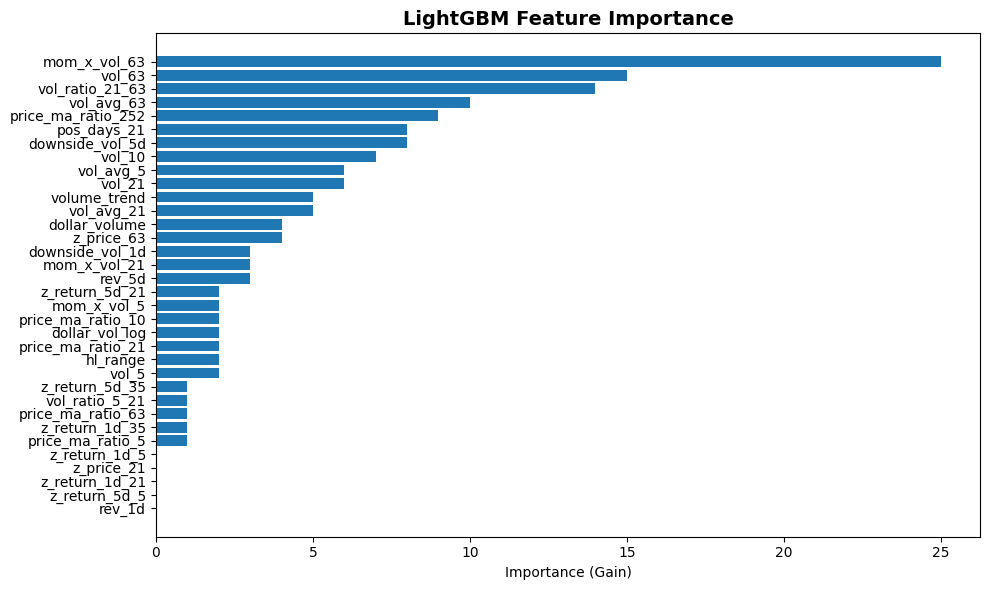

           feature  importance
      mom_x_vol_63          25
            vol_63          15
   vol_ratio_21_63          14
        vol_avg_63          10
price_ma_ratio_252           9
       pos_days_21           8
   downside_vol_5d           8
            vol_10           7
         vol_avg_5           6
            vol_21           6
      volume_trend           5
        vol_avg_21           5
     dollar_volume           4
        z_price_63           4
   downside_vol_1d           3
      mom_x_vol_21           3
            rev_5d           3
    z_return_5d_21           2
       mom_x_vol_5           2
 price_ma_ratio_10           2
    dollar_vol_log           2
 price_ma_ratio_21           2
          hl_range           2
             vol_5           2
    z_return_5d_35           1
    vol_ratio_5_21           1
 price_ma_ratio_63           1
    z_return_1d_35           1
  price_ma_ratio_5           1
     z_return_1d_5           0
        z_price_21           0
    z_re

In [139]:
importance = final_model.feature_importances_
feature_names = feature_cols

# Create dataframe
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importance
}).sort_values('importance', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(importance_df['feature'], importance_df['importance'])
plt.xlabel('Importance (Gain)')
plt.title('LightGBM Feature Importance', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print(importance_df.to_string(index=False))

# Top 5 features
top_5 = importance_df.head(5)['feature'].tolist()
print(f"\nTop 5 features: {top_5}")

Position sum check (should be ~0): 0.000000


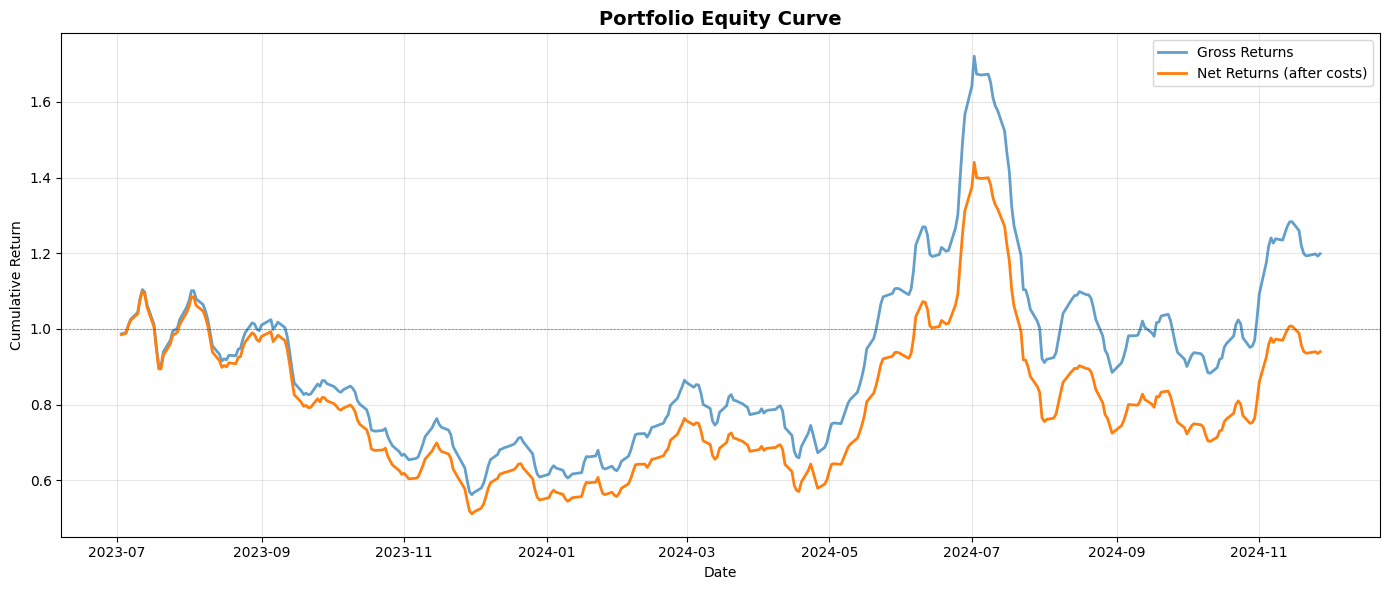

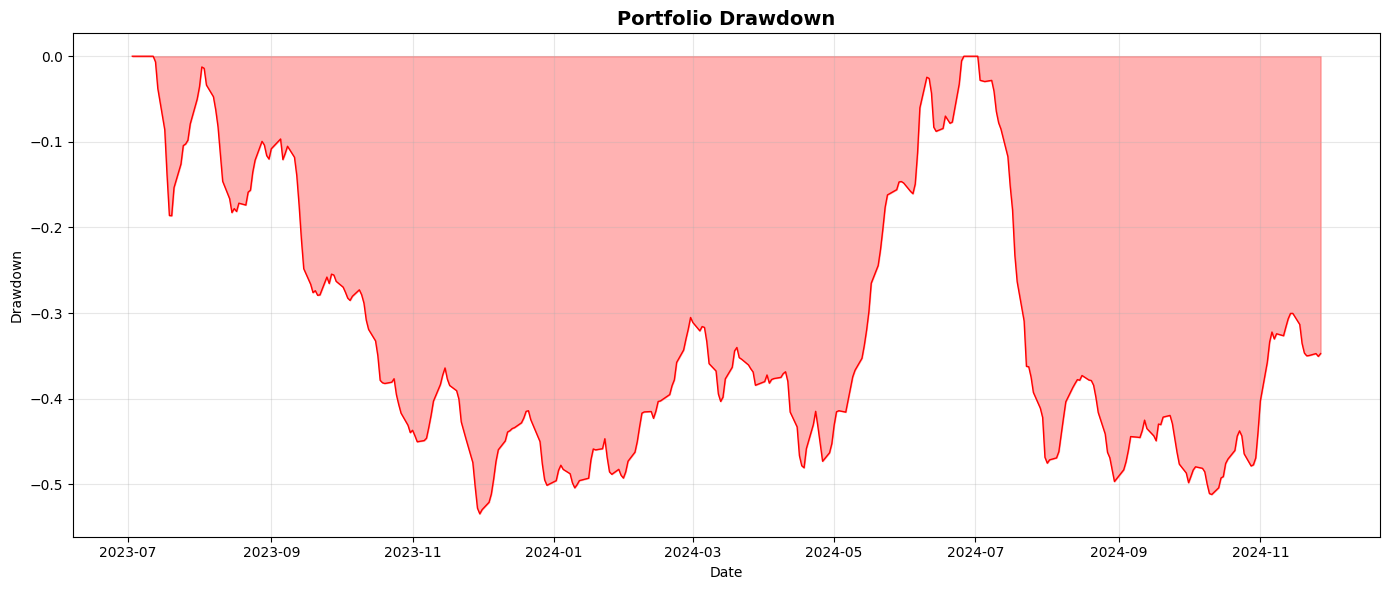

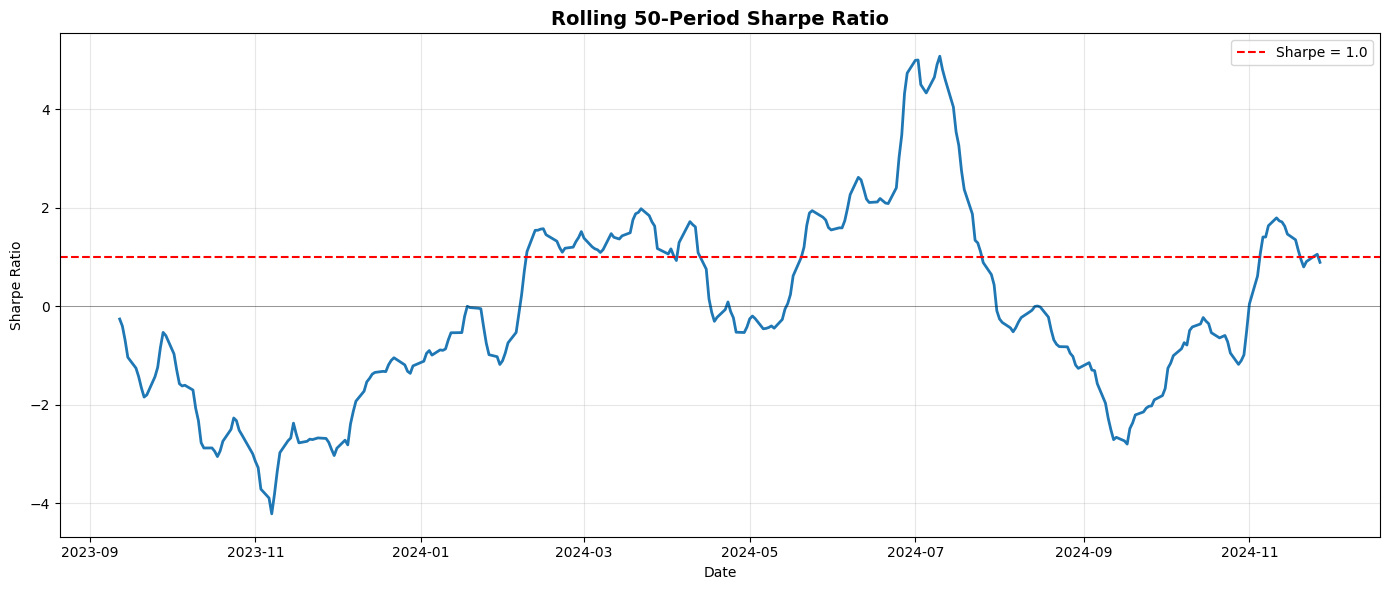

{'total_return': np.float64(-0.0600890656355183), 'ann_return': np.float64(0.007789961208995602), 'ann_vol': np.float64(0.18349978834304118), 'sharpe': np.float64(0.042452153647353344), 'max_drawdown': np.float64(-0.5344722361007458), 'win_rate': np.float64(0.5224719101123596), 'avg_turnover': np.float64(0.6828963795255931), 'avg_cost': np.float64(0.000682896379525593), 'n_periods': 356}


In [135]:
def perf_pipeline(test_df):
    
    test_df = construct_portfolio(test_df, pred_col='pred', top_pct=0.2, bottom_pct=0.2)

    portfolio_returns = stock_pnl_and_returns(test_df)

    portfolio_returns = turnover(test_df, portfolio_returns)

    portfolio_returns = apply_transaction_costs(portfolio_returns)

    metrics = performance_metrics(portfolio_returns, return_col='net_return', freq=52)
    
    plots(portfolio_returns)
    
    print(metrics)
    
perf_pipeline(test_df4)

Position sum check (should be ~0): 0.000000


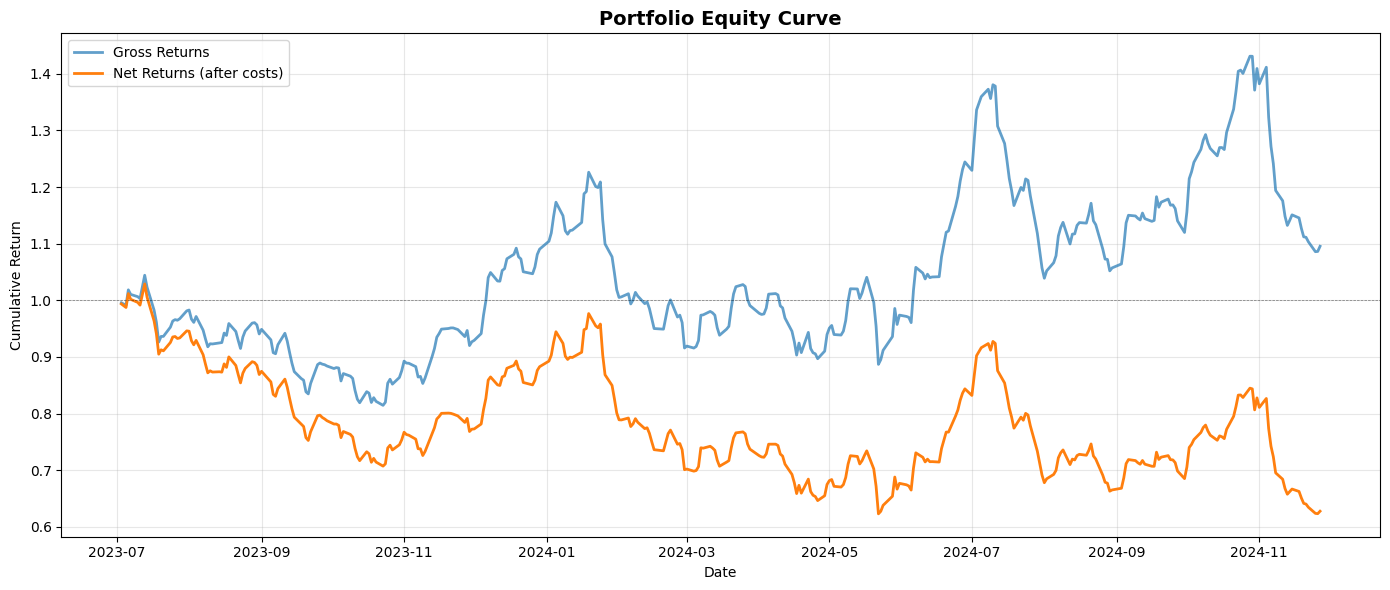

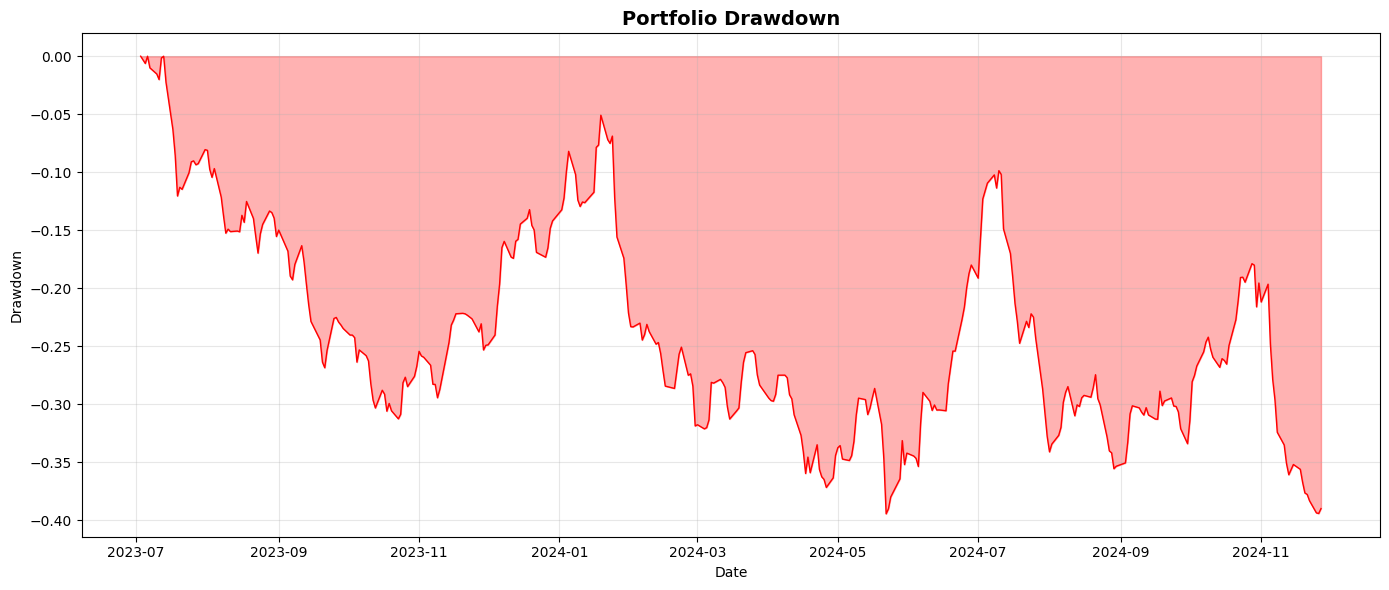

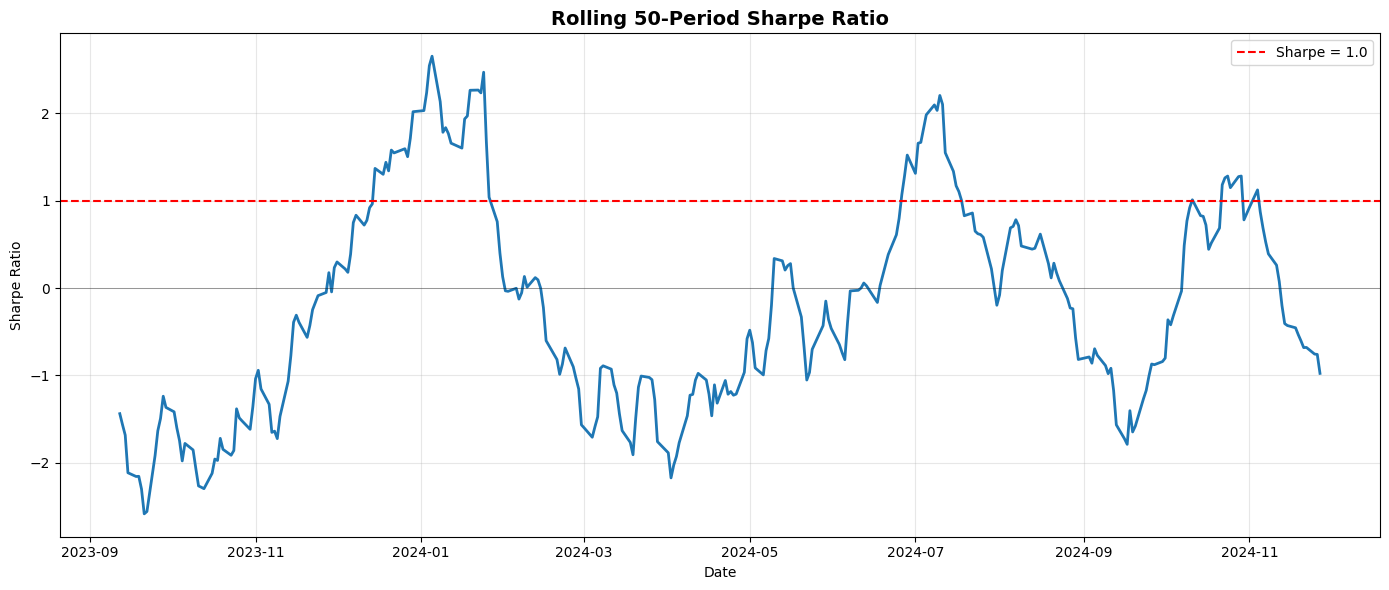

{'total_return': np.float64(-0.37239277832319995), 'ann_return': np.float64(-0.05752034136289759), 'ann_vol': np.float64(0.1447444167090717), 'sharpe': np.float64(-0.39739247060914484), 'max_drawdown': np.float64(-0.39457523273582196), 'win_rate': np.float64(0.4550561797752809), 'avg_turnover': np.float64(1.5629681647940077), 'avg_cost': np.float64(0.0015629681647940075), 'n_periods': 356}


In [136]:
def perf_pipeline(test_df):
    
    test_df = construct_portfolio(test_df, pred_col='pred', top_pct=0.2, bottom_pct=0.2)

    portfolio_returns = stock_pnl_and_returns(test_df)

    portfolio_returns = turnover(test_df, portfolio_returns)

    portfolio_returns = apply_transaction_costs(portfolio_returns)

    metrics = performance_metrics(portfolio_returns, return_col='net_return', freq=52)
    
    plots(portfolio_returns)
    
    print(metrics)
    
perf_pipeline(test_df2)

Second model despite having better test IC, has much higher turnover. That might be the cause of the lower performance

--------